# Automated Essay Scoring — Full Modelling Pipeline

## Pipeline Overview

1. Load & clean training data
2. Feature engineering (structural + TF-IDF + readability)
3. Train/validation split (stratified)
4. Model training & comparison
5. Hyperparameter tuning (best model)
6. Generate predictions on test set
7. Export predictions CSV + model pickle

## 1. Imports

In [13]:
import sys
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from tqdm_joblib import tqdm_joblib

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import cohen_kappa_score, make_scorer
from sklearn.model_selection import ParameterSampler
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import Ridge, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM not installed. Run: pip install lightgbm')

try:
    import textstat
    HAS_TEXTSTAT = True
except ImportError:
    HAS_TEXTSTAT = False
    print('textstat not installed. Run: pip install textstat')

print('All imports done.')
print(f'Python: {sys.version}')
print(f'NumPy: {np.__version__}  |  Pandas: {pd.__version__}')

All imports done.
Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
NumPy: 2.1.3  |  Pandas: 2.2.3


## 2. Paths — update BASE to your folder

In [2]:
BASE      = r"C:\\Users\\anand\\Documents\\Automated_essay_scoring"
PATH      = BASE + r"\\data\\raw\\"
PROCESSED = BASE + r"\\data\\processed\\"
EXPORT    = BASE + r"\\data\\model\\"

TRAIN_FILE = PATH + "train.csv"
TEST_FILE  = PATH + "test.csv"    # unlabelled — essay_id + full_text only
PRED_FILE  = PROCESSED + "test_predictions.csv"
MODEL_FILE = EXPORT + "aes_model.pkl"

## 3. Load Data

In [3]:
train = pd.read_csv(TRAIN_FILE)
test  = pd.read_csv(TEST_FILE)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Score range : {train["score"].min()} – {train["score"].max()}')
display(train.head(3))
display(test.head(3))

Train shape : (17307, 3)
Test shape  : (3, 2)
Score range : 1 – 6


,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4


,essay_id,full_text
0,000d118,Many people have car where they live. The thin...
1,000fe60,I am a scientist at NASA that is discussing th...
2,001ab80,People always wish they had the same technolog...


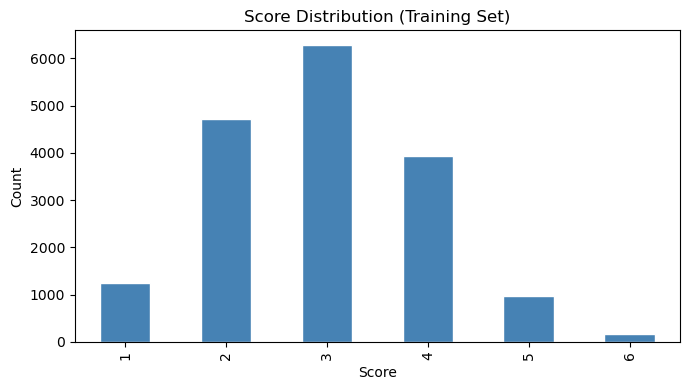

In [4]:
# Score distribution
fig, ax = plt.subplots(figsize=(7, 4))
train['score'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Score Distribution (Training Set)')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Text Cleaning

In [5]:
def clean_text(text: str) -> str:
    """Normalise essay text for TF-IDF vectorisation."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\n", " ", text)          # collapse newlines
    text = re.sub(r"[^a-z\s]", "", text)      # remove punctuation & digits
    text = re.sub(r"\s+", " ", text).strip()  # collapse whitespace
    return text

train['clean_text'] = train['full_text'].apply(clean_text)
test['clean_text']  = test['full_text'].apply(clean_text)

print('Cleaning done.')
print(train['clean_text'].iloc[0][:200])

Cleaning done.
many people have car where they live the thing they dont know is that when you use a car alot of thing can happen like you can get in accidet or the smoke that the car has is bad to breath on if someo


## 5. Feature Engineering

In [6]:
def sentence_count(text: str) -> int:
    if not isinstance(text, str) or not text.strip():
        return 0
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return len([s for s in sentences if s])


def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    """Extract all hand-crafted structural & readability features."""
    feat = pd.DataFrame(index=df.index)

    # --- Structural ---
    feat['essay_length']      = df['full_text'].apply(len)
    feat['word_count']        = df['full_text'].apply(lambda x: len(x.split()))
    feat['sentence_count']    = df['full_text'].apply(sentence_count)
    feat['paragraph_count']   = df['full_text'].apply(lambda x: len(x.split('\n\n')))
    feat['avg_word_length']   = df['full_text'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )

    # Protect against division by zero
    feat['avg_sentence_length'] = feat.apply(
        lambda r: r['word_count'] / r['sentence_count'] if r['sentence_count'] > 0 else 0,
        axis=1
    )
    feat['avg_paragraph_length'] = feat.apply(
        lambda r: r['word_count'] / r['paragraph_count'] if r['paragraph_count'] > 0 else 0,
        axis=1
    )

    # --- Vocabulary richness (lowercased, no punctuation) ---
    feat['unique_word_ratio'] = df['clean_text'].apply(
        lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0
    )

    # --- Readability (requires textstat) ---
    if HAS_TEXTSTAT:
        feat['flesch_kincaid_grade'] = df['full_text'].apply(textstat.flesch_kincaid_grade)
        feat['flesch_reading_ease']  = df['full_text'].apply(textstat.flesch_reading_ease)
        feat['gunning_fog']          = df['full_text'].apply(textstat.gunning_fog)

    return feat


train_feat = extract_features(train)
test_feat  = extract_features(test)

print(f'Features extracted: {train_feat.shape[1]} columns')
display(train_feat.describe())

Features extracted: 11 columns


,essay_length,word_count,sentence_count,paragraph_count,avg_word_length,avg_sentence_length,avg_paragraph_length,unique_word_ratio,flesch_kincaid_grade,flesch_reading_ease,gunning_fog
count,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000,17307.000000
mean,2071.617265,368.348241,18.504709,4.965274,4.536643,22.509867,89.813103,0.477053,9.556649,63.205308,11.884462
std,925.910701,150.394776,8.431053,3.311622,0.310465,16.290681,55.255187,0.075685,5.269797,15.874601,5.403141
min,712.000000,150.000000,1.000000,1.000000,3.441948,7.400000,4.560606,0.053744,1.716888,-632.715455,4.115965
25%,1397.000000,253.000000,12.000000,3.000000,4.320967,16.529412,60.500000,0.423379,7.494006,56.358991,9.736046
50%,1924.000000,345.000000,18.000000,5.000000,4.534527,19.769231,78.600000,0.473510,9.037044,64.164893,11.342697
75%,2541.000000,452.000000,24.000000,5.000000,4.750988,24.277778,102.400000,0.528012,10.759415,71.610937,13.151357
max,20459.000000,1656.000000,91.000000,66.000000,5.877500,715.000000,1656.000000,0.746914,279.136364,100.818873,288.573427


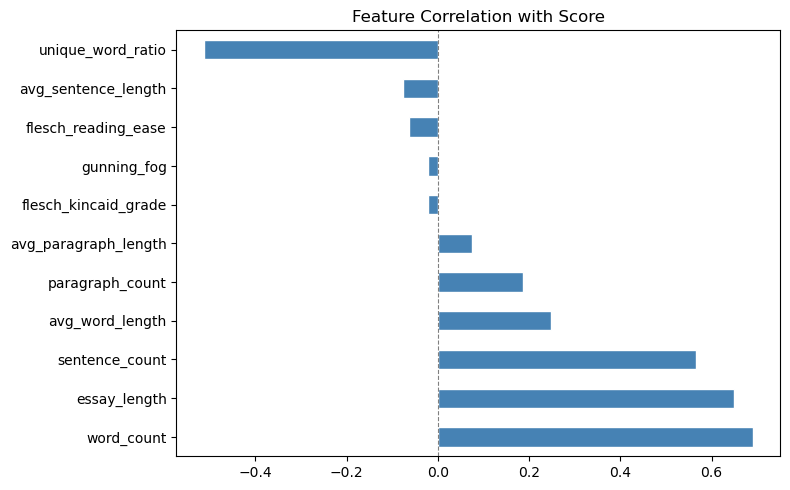

In [7]:
# Correlation of features with score
corr_df = train_feat.copy()
corr_df['score'] = train['score'].values

correlations = corr_df.corr()['score'].drop('score').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Correlation with Score')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Build Feature Matrix (TF-IDF + Structural)

In [8]:
# --- TF-IDF (fit ONLY on training data) ---
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,       # log-scale TF, reduces impact of high-freq terms
    min_df=3,                # ignore very rare terms
    strip_accents='unicode',
)

X_train_tfidf = vectorizer.fit_transform(train['clean_text'])   # fit on train only
X_test_tfidf  = vectorizer.transform(test['clean_text'])        # transform test

print(f'TF-IDF train matrix : {X_train_tfidf.shape}')
print(f'TF-IDF test matrix  : {X_test_tfidf.shape}')

# --- Scale structural features ---
scaler = StandardScaler()
X_train_struct = csr_matrix(scaler.fit_transform(train_feat.fillna(0)))
X_test_struct  = csr_matrix(scaler.transform(test_feat.fillna(0)))

# --- Combine ---
X_train = hstack([X_train_tfidf, X_train_struct])
X_test  = hstack([X_test_tfidf,  X_test_struct])
y_train = train['score'].values

print(f'Final train matrix  : {X_train.shape}')
print(f'Final test matrix   : {X_test.shape}')

TF-IDF train matrix : (17307, 5000)
TF-IDF test matrix  : (3, 5000)
Final train matrix  : (17307, 5011)
Final test matrix   : (3, 5011)


## 7. Model Comparison (Cross-Validated QWK)

In [9]:
# QWK scorer compatible with sklearn cross_val_score
def qwk_score(y_true, y_pred):
    # Round regression predictions to the nearest integer score
    y_pred_clipped = np.clip(np.round(y_pred).astype(int), 1, 6)
    return cohen_kappa_score(y_true, y_pred_clipped, weights='quadratic')

qwk_scorer = make_scorer(qwk_score)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define candidate models
# Ridge is treated as regression — predictions rounded to nearest score
candidates = {
    'Ridge (regression)': Ridge(alpha=1.0),
    'Random Forest':      RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'Linear SVC':         RidgeClassifier(alpha=1.0),
}

if HAS_LGB:
    candidates['LightGBM'] = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=63,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )

results = {}

for name, model in candidates.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=qwk_scorer, n_jobs=-1)
    results[name] = scores
    print(f'{name:<25}  QWK = {scores.mean():.4f}  ±{scores.std():.4f}')

Ridge (regression)         QWK = 0.7727  ±0.0062
Random Forest              QWK = 0.6695  ±0.0067
Linear SVC                 QWK = 0.6212  ±0.0114
LightGBM                   QWK = 0.7556  ±0.0069


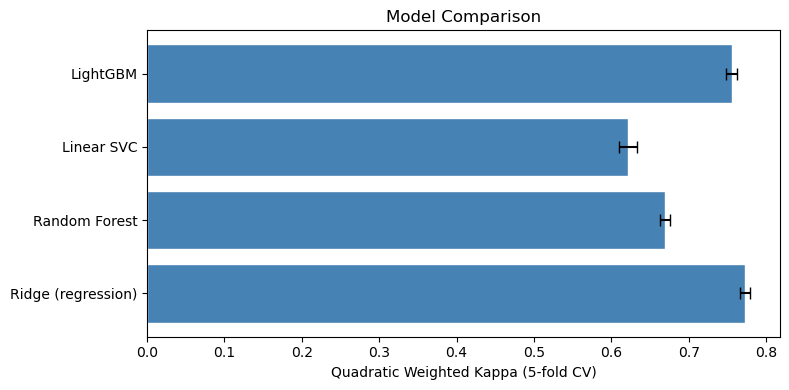

In [12]:
# Plot comparison
fig, ax = plt.subplots(figsize=(8, 4))
means = {k: v.mean() for k, v in results.items()}
stds  = {k: v.std()  for k, v in results.items()}
ax.barh(list(means.keys()), list(means.values()),
        xerr=list(stds.values()), color='steelblue', edgecolor='white', capsize=4)
ax.set_xlabel('Quadratic Weighted Kappa (5-fold CV)')
ax.set_title('Model Comparison')
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning (Best Model)

In [14]:
# Tune lightbgm
param_dist = {
    'n_estimators':   [300, 500, 800],
    'learning_rate':  [0.01, 0.05, 0.1],
    'num_leaves':     [31, 63, 127],
    'max_depth':      [-1, 6, 10],
    'min_child_samples': [10, 20, 50],
    'subsample':      [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}
base_model = lgb.LGBMClassifier(n_jobs=-1, random_state=42, verbose=-1)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=10,          # reduce iterations
    cv=3,               # fewer folds
    scoring=qwk_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=2,
)

with tqdm_joblib(tqdm(desc="Hyperparameter Search", total=30)):
    search.fit(X_train, y_train)

print(f'\nBest QWK (CV): {search.best_score_:.4f}')
print(f'Best params  : {search.best_params_}')

best_model = search.best_estimator_

Hyperparameter Search:   0%|                                                                    | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best QWK (CV): 0.7580
Best params  : {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.85}


In [20]:
# tune Ridge alpha
param_dist = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0, 50.0]}
base_model = Ridge()

search2 = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=10,          # reduce iterations
    cv=3,               # fewer folds
    scoring=qwk_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=2,
)

with tqdm_joblib(tqdm(desc="Hyperparameter Search", total=30)):
    search2.fit(X_train, y_train)

print(f'\nBest QWK (CV): {search2.best_score_:.4f}')
print(f'Best params  : {search2.best_params_}')

best_model_ridge = search2.best_estimator_

Hyperparameter Search:   0%|                                                                    | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best QWK (CV): 0.7731
Best params  : {'alpha': 1.0}


## 9. Final Model — Retrain on Full Training Set

In [15]:
best_model.fit(X_train, y_train)
print('Model retrained on full training set.')

Model retrained on full training set.


In [21]:
best_model_ridge.fit(X_train, y_train)
print('Model retrained on full training set.')

Model retrained on full training set.


## 10. Generate Test Predictions

In [16]:
raw_preds = best_model.predict(X_test)

# If using Ridge (regression), round and clip to valid score range
if hasattr(best_model, 'coef_') and not hasattr(best_model, 'classes_'):
    predictions = np.clip(np.round(raw_preds).astype(int), 1, 6)
else:
    predictions = raw_preds.astype(int)

submission = pd.DataFrame({
    'essay_id': test['essay_id'],
    'score':    predictions
})

display(submission.head(10))
print(f'\nPrediction distribution:')
print(submission['score'].value_counts().sort_index())

Hyperparameter Search:   0%|                                                                  | 0/30 [2:12:10<?, ?it/s]


,essay_id,score
0,000d118,3
1,000fe60,3
2,001ab80,4



Prediction distribution:
score
3    2
4    1
Name: count, dtype: int64


In [22]:
raw_preds = best_model_ridge.predict(X_test)

# If using Ridge (regression), round and clip to valid score range
if hasattr(best_model_ridge, 'coef_') and not hasattr(best_model_ridge, 'classes_'):
    predictions = np.clip(np.round(raw_preds).astype(int), 1, 6)
else:
    predictions = raw_preds.astype(int)

submission = pd.DataFrame({
    'essay_id': test['essay_id'],
    'score':    predictions
})

display(submission.head(10))
print(f'\nPrediction distribution:')
print(submission['score'].value_counts().sort_index())

,essay_id,score
0,000d118,2
1,000fe60,3
2,001ab80,4



Prediction distribution:
score
2    1
3    1
4    1
Name: count, dtype: int64


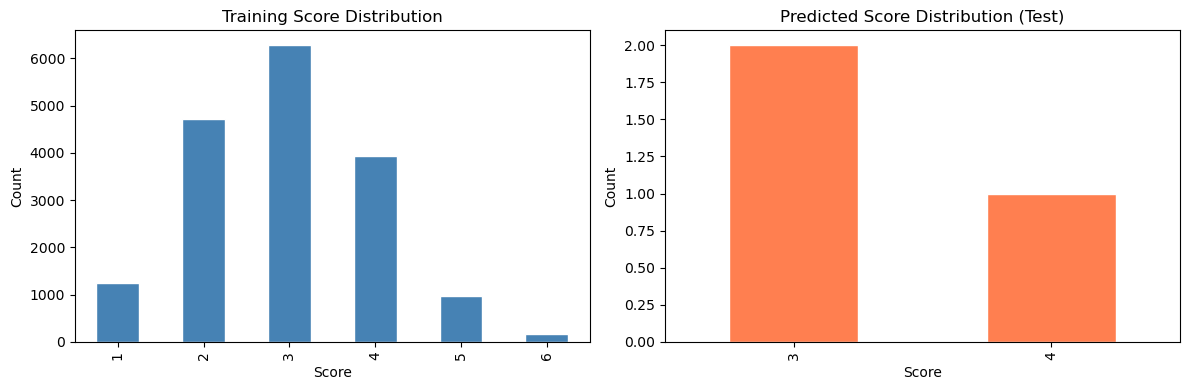

In [17]:
# Visualise predicted score distribution vs training distribution (lightgm)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['score'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white', title='Training Score Distribution')
submission['score'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='coral', edgecolor='white', title='Predicted Score Distribution (Test)')

for ax in axes:
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

Hyperparameter Search:   0%|                                                                    | 0/30 [00:05<?, ?it/s]


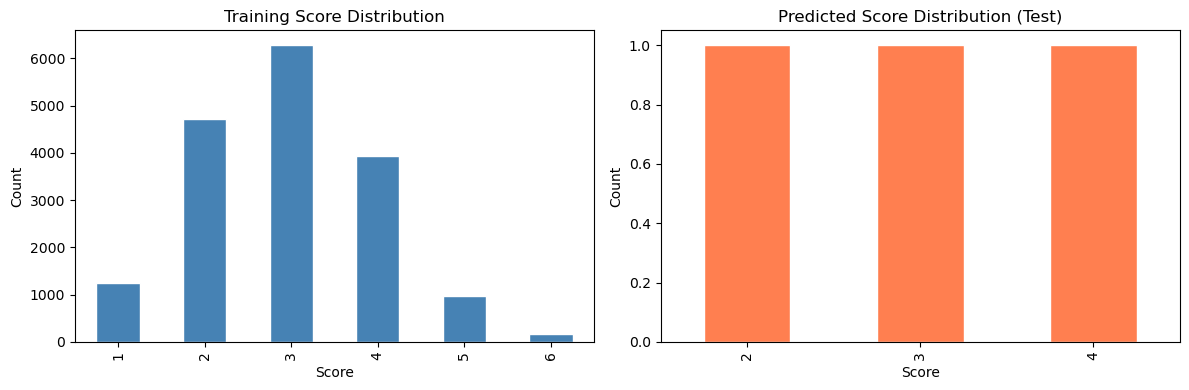

In [23]:
# Visualise predicted score distribution vs training distribution (ridge)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['score'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white', title='Training Score Distribution')
submission['score'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='coral', edgecolor='white', title='Predicted Score Distribution (Test)')

for ax in axes:
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 11. Export Predictions & Model

In [18]:
import os
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(EXPORT, exist_ok=True)

# Save predictions
submission.to_csv(PRED_FILE, index=False)
print(f'Predictions saved to: {PRED_FILE}')

# Save model + preprocessing objects
model_bundle = {
    'model':      best_model,
    'vectorizer': vectorizer,
    'scaler':     scaler,
}

with open(MODEL_FILE, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'Model bundle saved to: {MODEL_FILE}')
print('\nBundle contains: model, vectorizer, scaler')
print('Load with: bundle = pickle.load(open(MODEL_FILE, "rb"))')

Predictions saved to: C:\\Users\\anand\\Documents\\Automated_essay_scoring\\data\\processed\\test_predictions.csv
Model bundle saved to: C:\\Users\\anand\\Documents\\Automated_essay_scoring\\data\\model\\aes_model.pkl

Bundle contains: model, vectorizer, scaler
Load with: bundle = pickle.load(open(MODEL_FILE, "rb"))


## 12. Inference Helper

Use this to score a new essay without re-running the whole pipeline.

In [19]:
def predict_essay_score(essay_text: str, bundle: dict) -> int:
    """
    Score a single essay using the saved model bundle.

    Parameters
    ----------
    essay_text : str  — raw essay text
    bundle     : dict — loaded pickle containing model, vectorizer, scaler

    Returns
    -------
    int — predicted score (1–6)
    """
    model      = bundle['model']
    vectorizer = bundle['vectorizer']
    scaler     = bundle['scaler']

    # Build a single-row DataFrame to reuse extract_features
    row = pd.DataFrame({'full_text': [essay_text]})
    row['clean_text'] = row['full_text'].apply(clean_text)

    tfidf_vec = vectorizer.transform(row['clean_text'])
    struct_feat = extract_features(row).fillna(0)
    struct_vec = csr_matrix(scaler.transform(struct_feat))

    X = hstack([tfidf_vec, struct_vec])
    raw = model.predict(X)[0]

    # Round if regression model
    if isinstance(raw, float):
        return int(np.clip(round(raw), 1, 6))
    return int(raw)


# --- Quick sanity check ---
sample_essay = train['full_text'].iloc[0]
true_score   = train['score'].iloc[0]

bundle = pickle.load(open(MODEL_FILE, 'rb'))
pred   = predict_essay_score(sample_essay, bundle)

print(f'True score : {true_score}')
print(f'Predicted  : {pred}')

True score : 3
Predicted  : 3
